# Stage 2

### read in index references

In [117]:
import cartopy.crs as ccrs
import iris.plot as iplt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.interpolate import interp1d
import numpy as np
import datetime 

def plot_peak_check(ax, cube, catchment_poly, this_event_results, title):
    """
    Sanity check plot:
    - Full SM field at a given timestep
    - Catchment boundary
    - Peak cell marked as a scatter point
    - Neighbouring cells highlighted to confirm index alignment
    """
    
    x_coord = int(this_event_results['x_coord'])
    y_coord =int(this_event_results['y_coord'])
    x_idx_global = int(this_event_results['x_idx_global'])
    y_idx_global = int(this_event_results['y_idx_global'])
    
    sm_x = cube.coord('projection_x_coordinate').points
    sm_y = cube.coord('projection_y_coordinate').points
    dx   = sm_x[1] - sm_x[0]
    dy   = sm_y[1] - sm_y[0]

    # Full SM field
    iplt.pcolormesh(cube, axes=ax, cmap='Blues')

    # Catchment boundary
    from shapely.geometry import mapping
    import cartopy.feature as cfeature
    ax.add_geometries(
        [catchment_poly], crs=ccrs.OSGB(),
        facecolor='none', edgecolor='black', linewidth=1.5)

    # Peak cell as a box (so you can see it aligns with the pcolormesh grid)
    peak_box = plt.matplotlib.patches.Rectangle(
        (x_coord - dx/2, y_coord - dy/2), dx, dy,
        linewidth=2, edgecolor='red', facecolor='red', alpha=0.1,
        transform=ccrs.OSGB())
    ax.add_patch(peak_box)

    # Centre point
    ax.scatter(x_coord, y_coord, s=20, color='red', zorder=6,
               transform=ccrs.OSGB(), label=f'Peak ({x_idx_global}, {y_idx_global})')

    # Zoom to catchment with buffer
    minx, miny, maxx, maxy = catchment_poly.bounds
    buf = 20000  # 20km buffer
    ax.set_extent([minx-buf, maxx+buf, miny-buf, maxy+buf], crs=ccrs.OSGB())

#     ax.set_title(f"Peak cell check — global idx ({x_idx_global}, {y_idx_global})\n"
#                  f"coords ({x_coord:.0f}, {y_coord:.0f})")
    ax.set_title(title)
    ax.legend(loc='lower right')
    plt.tight_layout()

def find_temporal_profile(cube, details, plot):
    # Extract event time series
    values = cube.data[details['start_idx']:details['stop_idx']]
    times = cube.coord('yyyymmddhh').points[details['start_idx']:details['stop_idx']].astype(int)

    metrics = compute_temporal_metrics(values)
    
    # Convert to datetime
    dt = pd.to_datetime(times.astype(str), format="%Y%m%d%H")
    
    #temp_profile_dict = {'total_acc': values.sum(), 'times':dt, 'values':values}
    temp_profile_dict = {**metrics,'times': dt,'values': values}
    
    # Plot
    if plot == True:
        plt.figure(figsize=(8,4))
        plt.plot(dt, values, color='black')

        # Mark peak timestep
        rainfall_peak_time = cube.coord('yyyymmddhh').points[details['t_global']]
        peak_dt = pd.to_datetime(str(int(rainfall_peak_time)), format="%Y%m%d%H")
        plt.axvline(peak_dt, linestyle='--', color = 'red', label='Peak timestep')

        # Format ticks
        plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H'))

        plt.xlabel("Date")
        plt.ylabel("Precipitation intensity (mm/hr)")
        plt.title("Rainfall at peak grid cell during event")
        plt.legend()

        plt.tight_layout()
        plt.show()

    return temp_profile_dict

def compute_temporal_metrics(values):

    values = np.asarray(values).flatten()
    n = len(values)

    # --- Basic ---
    total_acc = np.nansum(values)

    # Peak position ratio
    peak_idx = np.argmax(values)
    peak_position_ratio = peak_idx / max(n - 1, 1)

    # --- D50 ---
    if total_acc > 0:
        cum = np.cumsum(values) / total_acc
        time_pct = np.linspace(0, 100, n)

        idx = np.where(cum >= 0.5)[0]
        if len(idx) > 0:
            i = idx[0]
            if i == 0:
                d50 = time_pct[0]
            else:
                x1, y1 = time_pct[i-1], cum[i-1]
                x2, y2 = time_pct[i],   cum[i]
                d50 = x1 + (0.5 - y1) * (x2 - x1) / (y2 - y1) if (y2 - y1) != 0 else np.nan
        else:
            d50 = np.nan
    else:
        d50 = np.nan

    # --- Gini coefficient (inequality of rainfall distribution) ---
    if n == 0 or np.all(values == 0):
        gini = 0.0
    else:
        s = np.sort(values)
        idx = np.arange(1, n + 1)
        gini = (2 * np.sum(idx * s) / (n * np.sum(s))) - (n + 1) / n

    # --- Time-based std (temporal spread around centre of mass) ---
    if total_acc > 0:
        pos = np.linspace(0, 1, n)  # normalised time
        t_cg = np.sum(pos * values) / total_acc
        time_based_std = np.sqrt(np.sum(((pos - t_cg) ** 2) * values) / total_acc)
    else:
        time_based_std = np.nan

    # --- Event dry ratio (%) ---
    rounded = np.round(values, 6)
    dry_ratio = np.count_nonzero(rounded == 0) / n * 100 if n > 0 else np.nan

    # --- 4th with most rainfall ---
    if total_acc > 0 and n > 1:
        cum = np.cumsum(values) / total_acc
        time_norm = np.linspace(0, 1, n)

        target_pts = np.linspace(0, 1, 4 + 1)  # 4 bins
        interp_func = interp1d(time_norm, cum, kind='linear', fill_value='extrapolate')

        resampled = interp_func(target_pts)
        fourth_with_most = int(np.argmax(np.diff(resampled)))
    else:
        fourth_with_most = np.nan

    return {
        'total_acc': total_acc,
        'peak_position_ratio': peak_position_ratio,
        'd50': d50,
        'gini': gini,
        'time_based_std': time_based_std,
        'dry_ratio': dry_ratio,
        'max_quartile_index': fourth_with_most
    }

def get_data_at_peak_cell(cube):

    x_idx_global = one_event_results['x_idx_global']
    y_idx_global = one_event_results['y_idx_global']

    x_coord =  one_event_results['x_coord']
    y_coord =  one_event_results['y_coord']

    cube_x = cube.coord('projection_x_coordinate').points
    cube_y = cube.coord('projection_y_coordinate').points

    # Check the coordinate at the global index matches what we stored
    assert np.isclose(cube_x[x_idx_global], x_coord, atol=100), \
        f"x mismatch: {cube_x[x_idx_global]} vs {x_coord}"
    assert np.isclose(cube_y[y_idx_global], y_coord, atol=100), \
        f"y mismatch: {cube_y[y_idx_global]} vs {y_coord}"

    # If those pass, extract the timeseries at that cell
    cube_at_peak = cube[:, y_idx_global, x_idx_global]
    return cube_at_peak  

In [14]:
import pandas as pd
import geopandas as gpd
import iris

from functions_clean import get_rainfall_cube, load_3d_cube, prepare_flood_cube, mask_cube_with_catchment

In [135]:
results = pd.read_csv("test.csv", dtype={'ens': str})
records = results.to_dict('records')
records

[{'max_precip': 30.504268646240234,
  't_global': 6178,
  'x_idx': 0,
  'y_idx': 12,
  'x_idx_global': 111,
  'y_idx_global': 125,
  'x_coord': 357500.0,
  'y_coord': 592500.0,
  'ens': '01',
  'year': 1992,
  'start_idx': 6177,
  'stop_idx': 6194,
  'rainfall_peak_day': '1992-08-18 00:00:00'},
 {'max_precip': 32.849205017089844,
  't_global': 5295,
  'x_idx': 4,
  'y_idx': 5,
  'x_idx_global': 115,
  'y_idx_global': 118,
  'x_coord': 377500.0,
  'y_coord': 557500.0,
  'ens': '01',
  'year': 1994,
  'start_idx': 5293,
  'stop_idx': 5303,
  'rainfall_peak_day': '1994-07-11 00:00:00'},
 {'max_precip': 56.2564811706543,
  't_global': 5394,
  'x_idx': 10,
  'y_idx': 3,
  'x_idx_global': 121,
  'y_idx_global': 116,
  'x_coord': 407500.0,
  'y_coord': 547500.0,
  'ens': '01',
  'year': 1994,
  'start_idx': 5384,
  'stop_idx': 5411,
  'rainfall_peak_day': '1994-07-15 00:00:00'},
 {'max_precip': 35.77378463745117,
  't_global': 6840,
  'x_idx': 8,
  'y_idx': 12,
  'x_idx_global': 119,
  'y_idx

In [22]:
# ------------ config
catchment_num = 23
event_num = 1
MOLLY_DIR_FF     = "/scratch/hydro4/users/kv25483/FutureFlood/"

In [23]:
catchments       = gpd.read_file(MOLLY_DIR_FF + "Data/CatchmentShapefiles/hyd_areas_GB_with_subcatchments.shp")
# catchment_lookup = pd.read_csv("/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/CEH_catchments/CEH_IHU_with_coastline/hyd_areas_GB_with_subcatchments_no_spaces.csv")
# catchment_lookup_dict = dict(zip(catchment_lookup["HA_NUM"], catchment_lookup["HA_NAME"]))
boundary_gdf    = catchments[catchments['HA_NUM'] == str(catchment_num)]
_CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

In [68]:
one_event_results = records[event_num]
ens_num = one_event_results['ens']
year = one_event_results['year']

In [25]:
### Get soil moisture data
sm_dir = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens_num}/'
sm_file = f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc"
sm = iris.load(sm_file)[0]
sm = mask_cube_with_catchment(sm, _CATCHMENT_POLY, 'full_cell')

### Get precipitation data
rainfall_cube_dir = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_yr_cube = get_rainfall_cube(year, ens_num, rainfall_cube_dir, _CATCHMENT_POLY)
rainfall_yr_cube = mask_cube_with_catchment(rainfall_yr_cube, _CATCHMENT_POLY, 'full_cell')

### Get flood output data
depth= 10
flood_dir = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/Ens{ens_num}_{catchment_num}/"
flood_area_cube = load_3d_cube(f"{flood_dir}/{depth}cm/flooded_area_5km_total_Ens{ens_num}_{catchment_num}_{depth}cm.nc")
flood_area_cube = prepare_flood_cube(flood_area_cube)
flood_area_cube = mask_cube_with_catchment(flood_area_cube, _CATCHMENT_POLY, 'full_cell')

# Get hydraulic conductivity data
HC_CUBE = iris.load(f"/scratch/hydro4/users/kv25483/FutureFlood/Data/HydraulicConductivity/5km_{catchment_num}.nc")[0]

### Spatial plot test

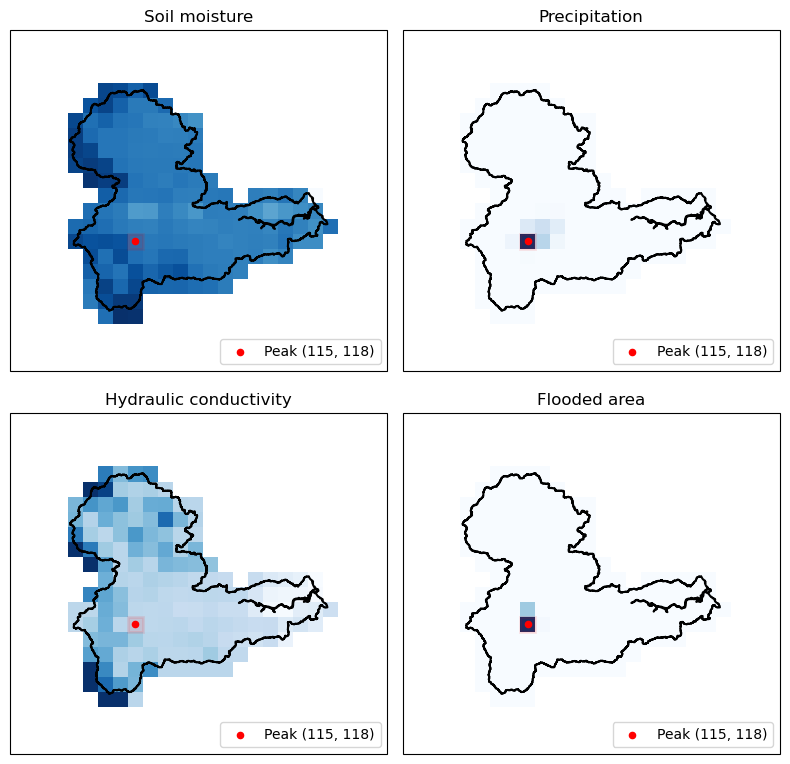

In [26]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(8, 8), subplot_kw={'projection': ccrs.OSGB()})
axs=axs.flatten()
plot_peak_check(axs[0], sm[1,:,:], _CATCHMENT_POLY, one_event_results, title = 'Soil moisture')
plot_peak_check(axs[1], rainfall_yr_cube[one_event_results['t_global'],:,:], 
                _CATCHMENT_POLY, one_event_results, title= 'Precipitation')
plot_peak_check(axs[2], HC_CUBE, _CATCHMENT_POLY, one_event_results, title = 'Hydraulic conductivity')
plot_peak_check(axs[3], flood_area_cube[event_num,:,:], _CATCHMENT_POLY, one_event_results, title = 'Flooded area')

### Extract the data

In [37]:
sm_at_peak = get_data_at_peak_cell(sm)
flood_at_peak = get_data_at_peak_cell(flood_area_cube)
flood_at_peak[event_num].data

array(0.0873, dtype=float32)

## Extract flood results at peak

In [58]:
flood_dir = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/Ens{ens_num}_{catchment_num}/"
flood_stats = {}
    
for depth in [10, 30]:
    area = load_3d_cube(
        f"{flood_dir}/{depth}cm/flooded_area_5km_total_Ens{ens_num}_{catchment_num}_{depth}cm.nc")
    vol = load_3d_cube(
        f"{flood_dir}/{depth}cm/flooded_volume_5km_total_Ens{ens_num}_{catchment_num}_{depth}cm.nc")

    area = prepare_flood_cube(area)
    vol  = prepare_flood_cube(vol)    
    
    area_at_peak = get_data_at_peak_cell(area)
    vol_at_peak = get_data_at_peak_cell(vol)
    
    flood_stats[f"{depth}cm_area"] =  area_at_peak[event_num].data
    flood_stats[f"{depth}cm_volume"] = vol_at_peak[event_num].data

## Extract rainfall temporal profile

In [ ]:
### Get precipitation data
rainfall_cube_dir = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_yr_cube = get_rainfall_cube(year, ens_num, rainfall_cube_dir, _CATCHMENT_POLY)

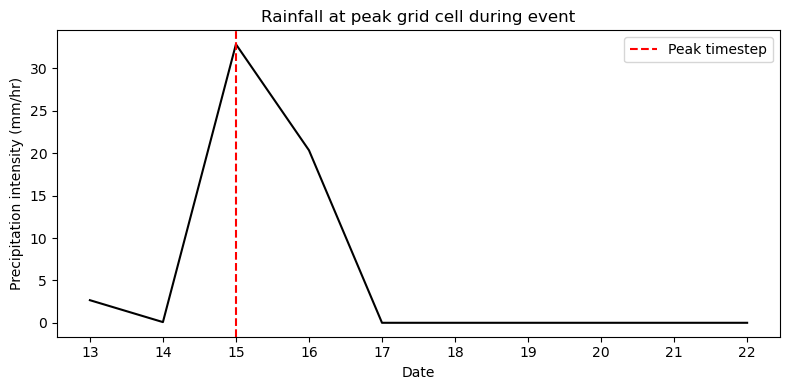

In [96]:
rainfall_at_peak = get_data_at_peak_cell(rainfall_yr_cube)
temp_profile_dict = find_temporal_profile(rainfall_at_peak, one_event_results, True)

### Extract soil moisture at peak

In [126]:
import datetime
import cftime

In [134]:
sm_at_peak = get_data_at_peak_cell(sm)
rainfall_peak_day = one_event_results['rainfall_peak_day']

In [133]:
# ======================================
# Soil moisture stats at peak cell
# ======================================
mean_sm_stats = {}
n_days_ls = [2, 3, 4, 5]

rainfall_peak_day = one_event_results['rainfall_peak_day']
tmp = datetime.datetime.strptime(rainfall_peak_day, '%Y-%m-%d %H:%M:%S')
rainfall_peak_day = cftime.Datetime360Day( tmp.year, tmp.month, tmp.day,tmp.hour, tmp.minute, tmp.second)

for n_days in n_days_ls:
    delta = datetime.timedelta(days=n_days)
    start_time = rainfall_peak_day - delta
    end_time = rainfall_peak_day  # exclusive of the peak day

    subset = sm_at_peak.extract(
        iris.Constraint(time=lambda cell: start_time <= cell.point < end_time))

    # Compute mean soil moisture
    if n_days == 1:
        mean_sm = subset.data
    else:
        mean_sm = subset.collapsed('time', iris.analysis.MEAN)

    mean_sm_stats[f'mean_sm_{n_days}_before_event'] = mean_sm.data # float(mean_sm.data)
mean_sm_stats

{'mean_sm_2_before_event': array(68.38184738),
 'mean_sm_3_before_event': array(69.08403269),
 'mean_sm_4_before_event': array(69.89161301),
 'mean_sm_5_before_event': array(70.76363831)}